CIT-227-024/2024 KYALE JAPETH

CCS 2226 - Foundations of AI (2026)

Task Two: Constraint Satisfaction Program

In [28]:
#import required libraries
import networkx as nx
import matplotlib.pyplot as plt


In [29]:
def is_safe(node, color, graph, assignment):
    # Check if any neighbor already has this color
    return all(assignment.get(neighbor) != color for neighbor in graph.get(node, []))


def backtrack_coloring(node_index, nodes, colors, graph, assignment):
    # If all nodes are colored, stop
    if node_index == len(nodes):
        return True

    node = nodes[node_index]

    # Try each available color
    for color in colors:
        if is_safe(node, color, graph, assignment):
            assignment[node] = color  # Assign color

            # Move to next node
            if backtrack_coloring(node_index + 1, nodes, colors, graph, assignment):
                return True

            del assignment[node]  # Backtrack

    return False  # No valid color found


def visualize(graph_dict, assignment, title):
    # Draw the graph with assigned colors
    G = nx.Graph(graph_dict)
    colors = [assignment.get(node, 'grey') for node in G.nodes()]

    plt.figure(figsize=(10, 8))
    plt.title(title, fontsize=16, fontweight='bold')

    nx.draw(
        G,
        nx.spring_layout(G, seed=42),
        with_labels=True,
        node_color=colors,
        node_size=3000,
        font_size=10,
        font_weight='bold',
        edge_color='gray'
    )
    plt.show()


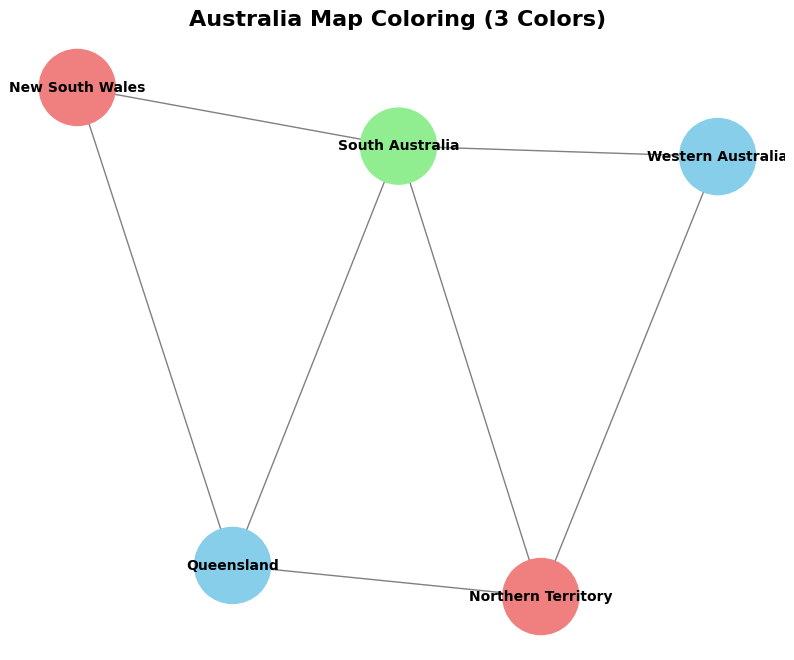

In [30]:
# Task A: Australia map coloring

aus_nodes = [
    'Western Australia', 'Northern Territory', 'South Australia',
    'Queensland', 'New South Wales'
]

# 3 available colors
aus_colors = ['skyblue', 'lightcoral', 'lightgreen']

# Adjacency list
aus_graph = {
    'Western Australia': ['Northern Territory', 'South Australia'],
    'Northern Territory': ['Western Australia', 'South Australia', 'Queensland'],
    'South Australia': ['Western Australia', 'Northern Territory', 'Queensland', 'New South Wales'],
    'Queensland': ['Northern Territory', 'South Australia', 'New South Wales'],
    'New South Wales': ['South Australia', 'Queensland']
}

aus_assignment = {}

# Run backtracking
backtrack_coloring(0, aus_nodes, aus_colors, aus_graph, aus_assignment)

# Visualize result
visualize(aus_graph, aus_assignment, "Australia Map Coloring (3 Colors)")


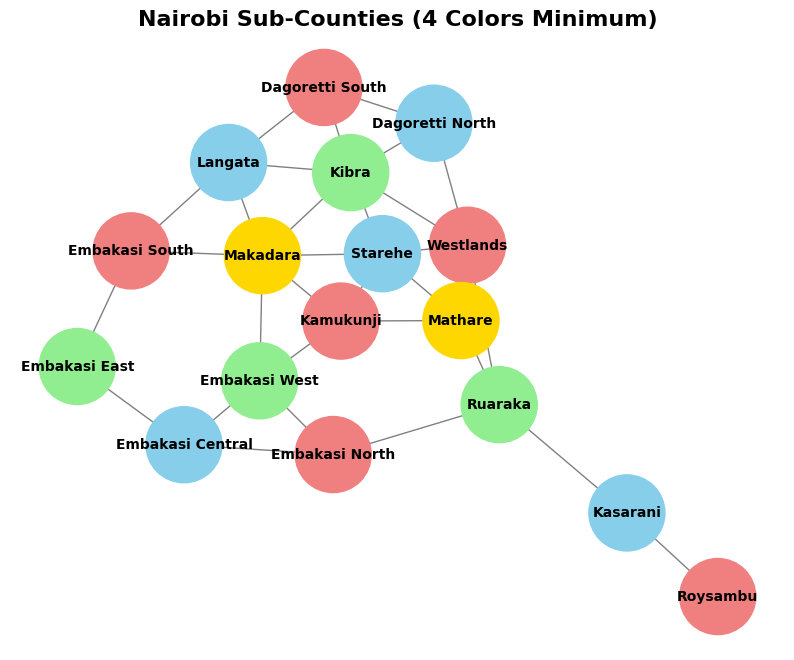

In [31]:
# Task B: Nairobi sub-county map coloring

nai_nodes = [
    'Westlands', 'Dagoretti North', 'Dagoretti South', 'Langata', 'Kibra',
    'Roysambu', 'Kasarani', 'Ruaraka', 'Embakasi South', 'Embakasi North',
    'Embakasi Central', 'Embakasi East', 'Embakasi West', 'Makadara',
    'Kamukunji', 'Starehe', 'Mathare'
]

# Adjacency list
nai_graph = {
    'Westlands': ['Dagoretti North', 'Kibra', 'Starehe', 'Mathare', 'Ruaraka'],
    'Dagoretti North': ['Westlands', 'Dagoretti South', 'Kibra'],
    'Dagoretti South': ['Dagoretti North', 'Kibra', 'Langata'],
    'Langata': ['Dagoretti South', 'Kibra', 'Makadara', 'Embakasi South'],
    'Kibra': ['Langata', 'Dagoretti South', 'Dagoretti North', 'Westlands', 'Starehe', 'Makadara'],
    'Starehe': ['Westlands', 'Kibra', 'Makadara', 'Kamukunji', 'Mathare'],
    'Mathare': ['Starehe', 'Westlands', 'Ruaraka', 'Kamukunji'],
    'Kamukunji': ['Starehe', 'Mathare', 'Makadara', 'Embakasi West'],
    'Makadara': ['Starehe', 'Kibra', 'Langata', 'Embakasi South', 'Embakasi West', 'Kamukunji'],
    'Ruaraka': ['Westlands', 'Mathare', 'Kasarani', 'Embakasi North'],
    'Kasarani': ['Ruaraka', 'Roysambu'],
    'Roysambu': ['Kasarani'],
    'Embakasi South': ['Langata', 'Makadara', 'Embakasi East'],
    'Embakasi North': ['Ruaraka', 'Embakasi Central', 'Embakasi West'],
    'Embakasi Central': ['Embakasi North', 'Embakasi East', 'Embakasi West'],
    'Embakasi East': ['Embakasi South', 'Embakasi Central'],
    'Embakasi West': ['Kamukunji', 'Makadara', 'Embakasi North', 'Embakasi Central']
}

# Up to 4 colors
palette = ['lightcoral', 'skyblue', 'lightgreen', 'gold']

# Try 1–4 colors and stop when valid
for i in range(1, 5):
    nai_assignment = {}
    if backtrack_coloring(0, nai_nodes, palette[:i], nai_graph, nai_assignment):
        visualize(nai_graph, nai_assignment, f"Nairobi Sub-Counties ({i} Colors Minimum)")
        break
